# Regression analysis

In [1]:
import re
import os
import pandas as pd
import plotnine as pln
from statsmodels.formula.api import ols

In [2]:
data = pd.read_csv('../data/viral/metadata/SARS2_BA1_SPIKE_Dadonaite.csv')
data

,ID,mutant,num_mutations,target,sequence
0,SARS2_BA1_M1I,M1I,1,-2.2303,IFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
1,SARS2_BA1_M1M,M1M,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
2,SARS2_BA1_M1T,M1T,1,-2.4823,TFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
3,SARS2_BA1_M1V,M1V,1,-2.3068,VFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
4,SARS2_BA1_F2F,F2F,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
...,...,...,...,...,...
10793,SARS2_BA1_S1249F,S1249F,1,0.3970,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10794,SARS2_BA1_S1249E,S1249E,1,-0.0168,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10795,SARS2_BA1_S1249C,S1249C,1,0.3963,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10796,SARS2_BA1_S1249A,S1249A,1,-0.0001,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...


In [3]:
mutation = 'N310T'

def split_mut_sit(mutation):
    parts = re.match(r'([A-Za-z])(\d+)(\S)', mutation) # \S for any non- white space
    if parts:
        return list(parts.groups())
    else:
        return [None, None, None]

split_mut_sit(mutation)

['N', '310', 'T']

In [4]:
data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
data

,ID,mutant,num_mutations,target,sequence,wt,site,mut
0,SARS2_BA1_M1I,M1I,1,-2.2303,IFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,I
1,SARS2_BA1_M1M,M1M,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,M
2,SARS2_BA1_M1T,M1T,1,-2.4823,TFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,T
3,SARS2_BA1_M1V,M1V,1,-2.3068,VFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,V
4,SARS2_BA1_F2F,F2F,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,F,2,F
...,...,...,...,...,...,...,...,...
10793,SARS2_BA1_S1249F,S1249F,1,0.3970,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,F
10794,SARS2_BA1_S1249E,S1249E,1,-0.0168,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,E
10795,SARS2_BA1_S1249C,S1249C,1,0.3963,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,C
10796,SARS2_BA1_S1249A,S1249A,1,-0.0001,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,A


In [5]:
data.dtypes

ID                object
mutant            object
num_mutations      int64
target           float64
sequence          object
wt                object
site              object
mut               object
dtype: object

In [6]:
model = ols('target ~ site', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     6.196
Date:                Mon, 08 Sep 2025   Prob (F-statistic):               0.00
Time:                        13:13:04   Log-Likelihood:                -12957.
No. Observations:               10798   AIC:                         2.841e+04
Df Residuals:                    9549   BIC:                         3.751e+04
Df Model:                        1248                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.7548      0.427     -4.109   

# Viral

In [5]:
base_dir = '../data/viral/metadata/'
res = {}
for file in os.listdir(base_dir):
    file_path = os.path.join(base_dir, file)
    dts = file.split('.csv')[0]
    data = pd.read_csv(file_path)
    
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    data['site'] = data['site'].astype(str)
    model1 = ols('target ~ site', data=data).fit()
    model2 = ols('target ~ mut', data=data).fit()
    model3 = ols('target ~ site+mut', data=data).fit()
    res[dts] = [round(float(model1.rsquared), 4), round(float(model2.rsquared), 4), round(float(model3.rsquared), 4)]


df = pd.DataFrame.from_dict(res, orient='index').reset_index()
df.rename(columns={'index': 'Dataset', 0:'R2_site', 1:'R2_mut', 2:'R2_site+mut'}, inplace=True)
df['Source'] = 'Viral'
df

,Dataset,R2_site,R2_mut,R2_site+mut,Source
0,HIV1_HV1B9_ENV_DuenasDecamp,0.3107,0.0398,0.3486,Viral
1,BPP22_COAT_Tsuboyama,0.6027,0.1601,0.7677,Viral
2,AAV2_CAPSD_Sinai,0.2419,0.0799,0.2958,Viral
3,IAV_RDRP_Li,0.3660,0.0515,0.4163,Viral
4,EV_CAPSD_Bakhache,0.3232,0.0362,0.3599,Viral
5,CVB3_2B_Alvarez,0.3422,0.1158,0.4581,Viral
6,CVB3_3B_Alvarez,0.4537,0.0711,0.5248,Viral
7,PESV_POLG_Tsuboyama,0.4946,0.0666,0.5531,Viral
8,RsYN04_RBD_Starr,0.6774,0.0062,0.6834,Viral
9,DENV_POLG_Suphatrakul,0.5958,0.0537,0.6494,Viral


## Cellular

In [7]:
base_dir = '../data/cellular/metadata/'
res_nonviral = {}
for file in os.listdir(base_dir):
    dts = file.split('.csv')[0]
    file_path = os.path.join(base_dir, file)
    data = pd.read_csv(file_path)
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    data = data.dropna()
    model1 = ols('target ~ site', data=data).fit()
    model2 = ols('target ~ mut', data=data).fit()
    model3 = ols('target ~ site+mut', data=data).fit()
    res_nonviral[dts] = [round(float(model1.rsquared), 4), round(float(model2.rsquared), 4), round(float(model3.rsquared), 4)]

df2 = pd.DataFrame.from_dict(res_nonviral, orient='index').reset_index()
df2.rename(columns={'index': 'Dataset', 0:'R2_site', 1:'R2_mut', 2:'R2_site+mut'}, inplace=True)
df2['Source'] = 'Cellular'
df2

,Dataset,R2_site,R2_mut,R2_site+mut,Source
0,TIM_THETH,0.4950,0.0629,0.5578,Cellular
1,TIM_THEMA,0.4405,0.0460,0.4836,Cellular
2,MK01_HUMAN_Johannessen,0.2512,0.0356,0.2861,Cellular
3,IF1_ECOLI,0.5028,0.0872,0.5903,Cellular
4,TIM_SULSO,0.4565,0.0691,0.5257,Cellular
5,RL401_YEAST_Fraser2016,0.4519,0.0630,0.5154,Cellular
6,RASH_HUMAN_Kuriyan,0.5455,0.0513,0.5948,Cellular
7,MTH3_HAEAESTABILIZED_Tawfik2015,0.5626,0.0356,0.5813,Cellular
8,AMIE_PSEAE_Whitehead,0.4708,0.0449,0.5166,Cellular
9,TPMT_HUMAN_Fowler2018,0.3431,0.1491,0.4886,Cellular


In [8]:
res_full = pd.concat([df, df2])
res_melt = res_full.melt(id_vars=['Dataset', 'Source'], value_vars=['R2_site', 'R2_mut', 'R2_site+mut'], var_name='Model', value_name='R2')
res_melt

,Dataset,Source,Model,R2
0,HIV1_HV1B9_ENV_DuenasDecamp,Viral,R2_site,0.3107
1,BPP22_COAT_Tsuboyama,Viral,R2_site,0.6027
2,AAV2_CAPSD_Sinai,Viral,R2_site,0.2419
3,IAV_RDRP_Li,Viral,R2_site,0.3660
4,EV_CAPSD_Bakhache,Viral,R2_site,0.3232
...,...,...,...,...
232,B3VI55_LIPST_Whitehead2015,Cellular,R2_site+mut,0.2705
233,B3VI55_LIPSTSTABLE,Cellular,R2_site+mut,0.4354
234,RL401_YEAST_Bolon2013,Cellular,R2_site+mut,0.5773
235,RL401_YEAST_Bolon2014,Cellular,R2_site+mut,0.5871


In [ ]:
#res_melt.to_csv('../experiments/OLS_results.csv')

# PLots

In [2]:
import pandas as pd
import plotnine as pln

In [ ]:
# res_melt = pd.read_csv('../experiments/OLS_results.csv', index_col=0)
# res_melt

In [11]:
res_melt['Model'] = res_melt['Model'].str.replace('R2_', '',)
res_melt

,Dataset,Source,Model,R2
0,HIV1_HV1B9_ENV_DuenasDecamp,Viral,site,0.3107
1,BPP22_COAT_Tsuboyama,Viral,site,0.6027
2,AAV2_CAPSD_Sinai,Viral,site,0.2419
3,IAV_RDRP_Li,Viral,site,0.3660
4,EV_CAPSD_Bakhache,Viral,site,0.3232
...,...,...,...,...
232,B3VI55_LIPST_Whitehead2015,Cellular,site+mut,0.2705
233,B3VI55_LIPSTSTABLE,Cellular,site+mut,0.4354
234,RL401_YEAST_Bolon2013,Cellular,site+mut,0.5773
235,RL401_YEAST_Bolon2014,Cellular,site+mut,0.5871


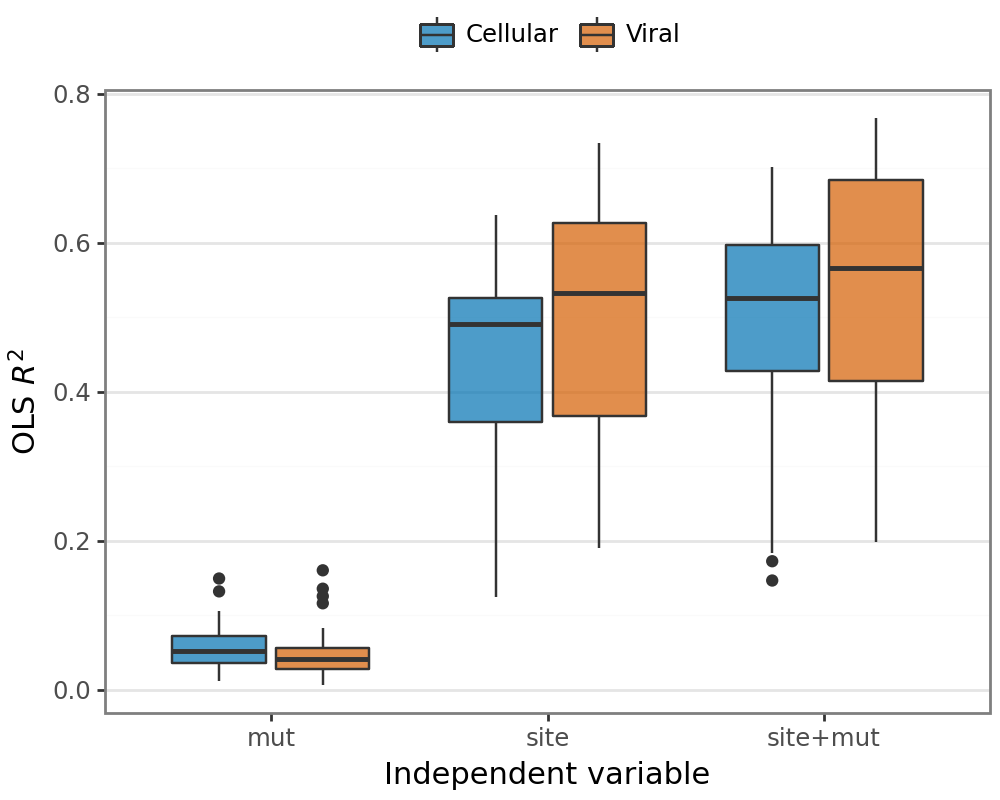

In [106]:
plot = (
    #pln.ggplot(res_melt, pln.aes(y='R2', x='Source', color='Model'))
    pln.ggplot(res_melt, pln.aes(y='R2', x='Model', fill='Source'))
    + pln.scale_fill_manual(values={"Viral": "#D55E00", "Cellular": "#0072B2"})
    + pln.geom_boxplot(alpha=0.7)
    + pln.theme_bw()
    + pln.theme(figure_size=(5,4), panel_grid_major_x=pln.element_blank(), legend_position='top', legend_title=pln.element_blank())
    +pln.labs(
        y='OLS $R^2$',
        x='Independent variable'
    )
    )

plot#.save('../experiments/OLS/OLS_site_categorical_source.png', dpi=600)

# AVG model vs LassoCV

In [3]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

In [4]:
lassoCV = pd.DataFrame()
#for model in ['esm2_650m', 'esmc_600m', 'rsawhney_esm2_3B', 'esm2_viral_650m_MP15', 'esm2_viral_650m_MP15_partial']:
for model in ['esm2_650m', 'esm2_viral_650m_MP15']:
    for source in ['viral', 'cellular']:
        for method in ['pool_split', 'site_split']:
            res_dir_path = f'../experiments/lassoCV/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
            res['Source'] = source
            res['Split'] = method
            
            lassoCV = pd.concat([lassoCV, res], ignore_index=True)

rename_map = {
    'esm2_viral_650m_MP15_partial':'esm2_viral_partial', 
    'esm2_viral_650m_MP15':'esm2_viral_full',
    'pool_split':'pooled',
    'site_split':'site',

    }

lassoCV.replace(rename_map, inplace=True)
lassoCV = lassoCV.rename(columns={'R2_score_test':"lassoCV_R2"})
lassoCV

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,lassoCV_R2,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_nonzero_coefs,Dataset,Source,Split
0,esm2_650m,1,5.950658e-01,0.465875,0.642610,0.499775,0.496724,0.678049,0.623398,0.544245,267,SARS2_PRD0038_RBD_Starr,viral,pooled
1,esm2_650m,2,6.038621e-01,0.452948,0.627526,0.520908,0.502435,0.700182,0.624444,0.596304,276,SARS2_PRD0038_RBD_Starr,viral,pooled
2,esm2_650m,3,5.895079e-01,0.472382,0.652183,0.407867,0.495722,0.709779,0.622881,0.528574,246,SARS2_PRD0038_RBD_Starr,viral,pooled
3,esm2_650m,1,4.520342e-01,0.520602,0.729537,0.231151,0.688557,0.925848,0.627984,0.397335,44,HIV1_HV1B9_ENV_DuenasDecamp,viral,pooled
4,esm2_650m,2,5.037395e-01,0.510456,0.698138,0.244454,0.645255,0.898591,0.658186,0.418242,53,HIV1_HV1B9_ENV_DuenasDecamp,viral,pooled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,esm2_viral_full,2,1.446320e-02,0.853103,0.990483,0.002679,0.862942,1.006335,0.122160,0.079819,3,TPK1_HUMAN_Roth2017,cellular,site
884,esm2_viral_full,3,1.879569e-02,0.846657,0.986000,0.014049,0.869129,1.010785,0.141401,0.107775,9,TPK1_HUMAN_Roth2017,cellular,site
885,esm2_viral_full,1,3.458211e-03,0.801426,1.045298,-0.003626,0.595838,0.791708,0.077023,0.038142,1,UBE4B_MOUSE_Klevit2013_singles,cellular,site
886,esm2_viral_full,2,0.000000e+00,0.773593,1.014889,-0.000452,0.705582,0.940790,NaN,NaN,0,UBE4B_MOUSE_Klevit2013_singles,cellular,site


In [5]:
cols=['Model', 'Source', 'Dataset', 'Split', 'lassoCV_R2']
lassoCV = lassoCV[cols]
lassoCV = lassoCV.groupby(['Model', 'Source', 'Dataset', 'Split'], as_index=False)['lassoCV_R2'].mean()
lassoCV

,Model,Source,Dataset,Split,lassoCV_R2
0,esm2_650m,cellular,AMIE_PSEAE_Whitehead,pooled,0.477524
1,esm2_650m,cellular,AMIE_PSEAE_Whitehead,site,0.222458
2,esm2_650m,cellular,B3VI55_LIPSTSTABLE,pooled,0.451530
3,esm2_650m,cellular,B3VI55_LIPSTSTABLE,site,0.268583
4,esm2_650m,cellular,B3VI55_LIPST_Whitehead2015,pooled,0.245162
...,...,...,...,...,...
291,esm2_viral_full,viral,SARS2_RBD_binding_Starr,site,0.057320
292,esm2_viral_full,viral,SARS2_RBD_expression_Starr,pooled,0.629590
293,esm2_viral_full,viral,SARS2_RBD_expression_Starr,site,0.105002
294,esm2_viral_full,viral,SARS2_XBB15_RBD_Taylor,pooled,0.671039


In [6]:
res_avg = pd.read_csv('../experiments/AVG/results_AVG_3folds_all.csv', index_col=0)
res_avg = res_avg[['Source', 'Dataset', 'Split', 'Fold', 'R2_score_test']]
res_avg = res_avg.groupby(['Source', 'Dataset', 'Split'], as_index=False)['R2_score_test'].mean()
res_avg = res_avg.rename(columns={'R2_score_test':"R2"})
res_avg

,Source,Dataset,Split,R2
0,cellular,AMIE_PSEAE_Whitehead,pooled,0.405258
1,cellular,AMIE_PSEAE_Whitehead,site,-0.003366
2,cellular,B3VI55_LIPSTSTABLE,pooled,0.254094
3,cellular,B3VI55_LIPSTSTABLE,site,-0.004476
4,cellular,B3VI55_LIPST_Whitehead2015,pooled,0.162333
...,...,...,...,...
143,viral,SARS2_RBD_binding_Starr,site,-0.014292
144,viral,SARS2_RBD_expression_Starr,pooled,0.695023
145,viral,SARS2_RBD_expression_Starr,site,-0.009377
146,viral,SARS2_XBB15_RBD_Taylor,pooled,0.629746


In [7]:
res = res_avg.merge(lassoCV, on=['Source', 'Dataset', 'Split'], how='inner')
res = res.query('Split == "pooled"')
res

,Source,Dataset,Split,R2,Model,lassoCV_R2
0,cellular,AMIE_PSEAE_Whitehead,pooled,0.405258,esm2_650m,0.477524
1,cellular,AMIE_PSEAE_Whitehead,pooled,0.405258,esm2_viral_full,0.402451
4,cellular,B3VI55_LIPSTSTABLE,pooled,0.254094,esm2_650m,0.451530
5,cellular,B3VI55_LIPSTSTABLE,pooled,0.254094,esm2_viral_full,0.344551
8,cellular,B3VI55_LIPST_Whitehead2015,pooled,0.162333,esm2_650m,0.245162
...,...,...,...,...,...,...
285,viral,SARS2_RBD_binding_Starr,pooled,0.613546,esm2_viral_full,0.596771
288,viral,SARS2_RBD_expression_Starr,pooled,0.695023,esm2_650m,0.571781
289,viral,SARS2_RBD_expression_Starr,pooled,0.695023,esm2_viral_full,0.629590
292,viral,SARS2_XBB15_RBD_Taylor,pooled,0.629746,esm2_650m,0.488932


In [8]:
res.groupby(['Model'])['lassoCV_R2'].mean()

Model
esm2_650m          0.429320
esm2_viral_full    0.394653
Name: lassoCV_R2, dtype: float64

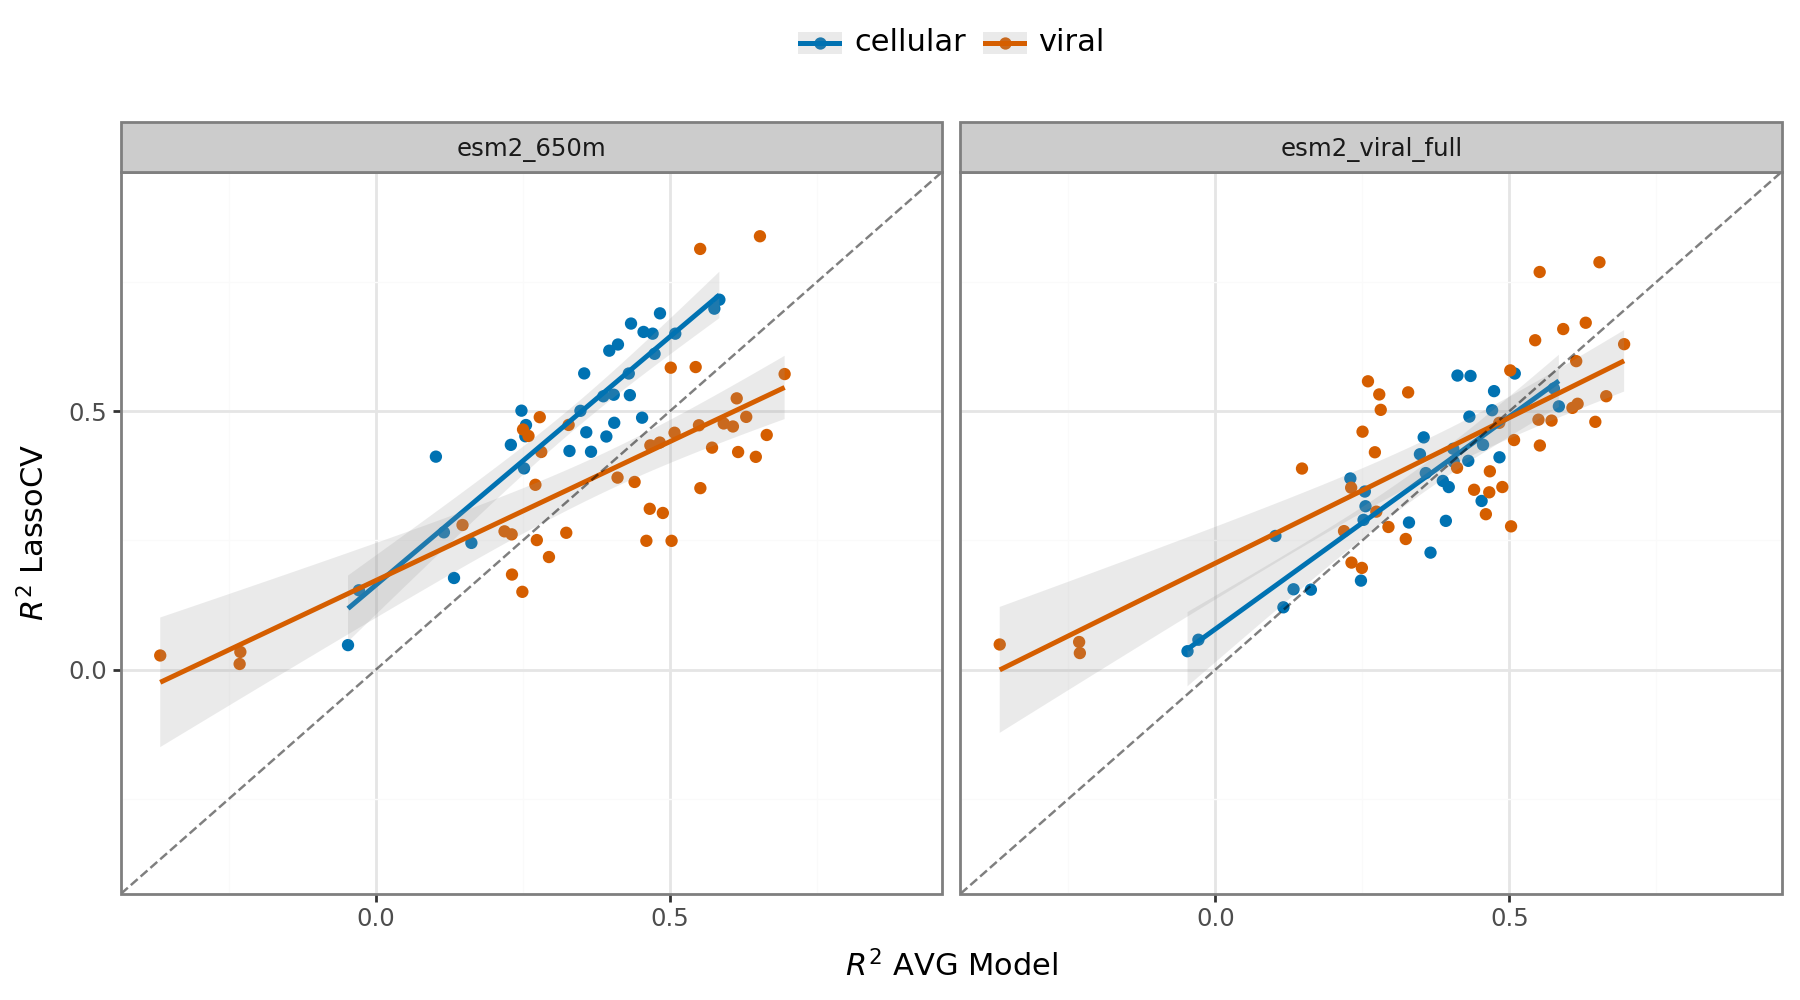

In [11]:
plot = (
    pln.ggplot(res, pln.aes(y='lassoCV_R2', x='R2', color='Source'))
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point()
    + pln.geom_smooth(method='lm', se=True,alpha=.2)
    + pln.theme_bw(11)
    + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
    + pln.theme(
        figure_size=(9,5),
        legend_position='top',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    + pln.facet_wrap('~Model', scales='fixed')
    + pln.xlim(-0.37, 0.9)
    + pln.ylim(-0.37, 0.9)
    + pln.labs(
        y="$R^2$ LassoCV",
        x="$R^2$ AVG Model"
    )
    )

plot#.save('../experiments/AVG/AVG_x_lassCV.png', dpi=600)

## AVG model vs finetuned model

In [97]:
res_esm2 = pd.read_csv('../experiments_v01/fineTune/res_finetune_esm2_650m.csv', index_col=0)
res_esm2 = res_esm2[['Source', 'Dataset', 'split_strategy', 'val_r2']]
res_esm2 = res_esm2.rename(columns={'split_strategy':"Split", 'val_r2':'ESM-2_R2'})
replace_map = {'Pool Split':'pooled', 'Site Split':'site', 'Viral':'viral', 'Cellular':'cellular'}
res_esm2 = res_esm2.replace(replace_map)
res_esm2

,Source,Dataset,Split,ESM-2_R2
0,viral,BPP22_COAT_Tsuboyama,pooled,0.737966
1,viral,BPP22_COAT_Tsuboyama,site,0.615722
2,viral,CVB3_2A_Alvarez,pooled,0.463681
3,viral,CVB3_2A_Alvarez,site,0.106359
4,viral,CVB3_2B_Alvarez,pooled,0.393990
...,...,...,...,...
61,cellular,UBC9_HUMAN_Roth2017,site,0.144218
62,cellular,UBE4B_MOUSE_Klevit2013_singles,pooled,-0.010066
63,cellular,UBE4B_MOUSE_Klevit2013_singles,site,-0.000251
64,cellular,YAP1_HUMAN_Fields2012_singles,pooled,0.191104


In [98]:
res = res_esm2.merge(res_avg, on=['Source', 'Dataset', 'Split'], how='inner')
res

,Source,Dataset,Split,ESM-2_R2,R2
0,viral,BPP22_COAT_Tsuboyama,pooled,0.737966,0.551416
1,viral,BPP22_COAT_Tsuboyama,site,0.615722,-0.047663
2,viral,CVB3_2A_Alvarez,pooled,0.463681,0.543750
3,viral,CVB3_2A_Alvarez,site,0.106359,-0.047608
4,viral,CVB3_2B_Alvarez,pooled,0.393990,0.259436
...,...,...,...,...,...
141,cellular,UBC9_HUMAN_Roth2017,site,0.144218,-0.017548
142,cellular,UBE4B_MOUSE_Klevit2013_singles,pooled,-0.010066,0.115625
143,cellular,UBE4B_MOUSE_Klevit2013_singles,site,-0.000251,-0.004356
144,cellular,YAP1_HUMAN_Fields2012_singles,pooled,0.191104,0.357715


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


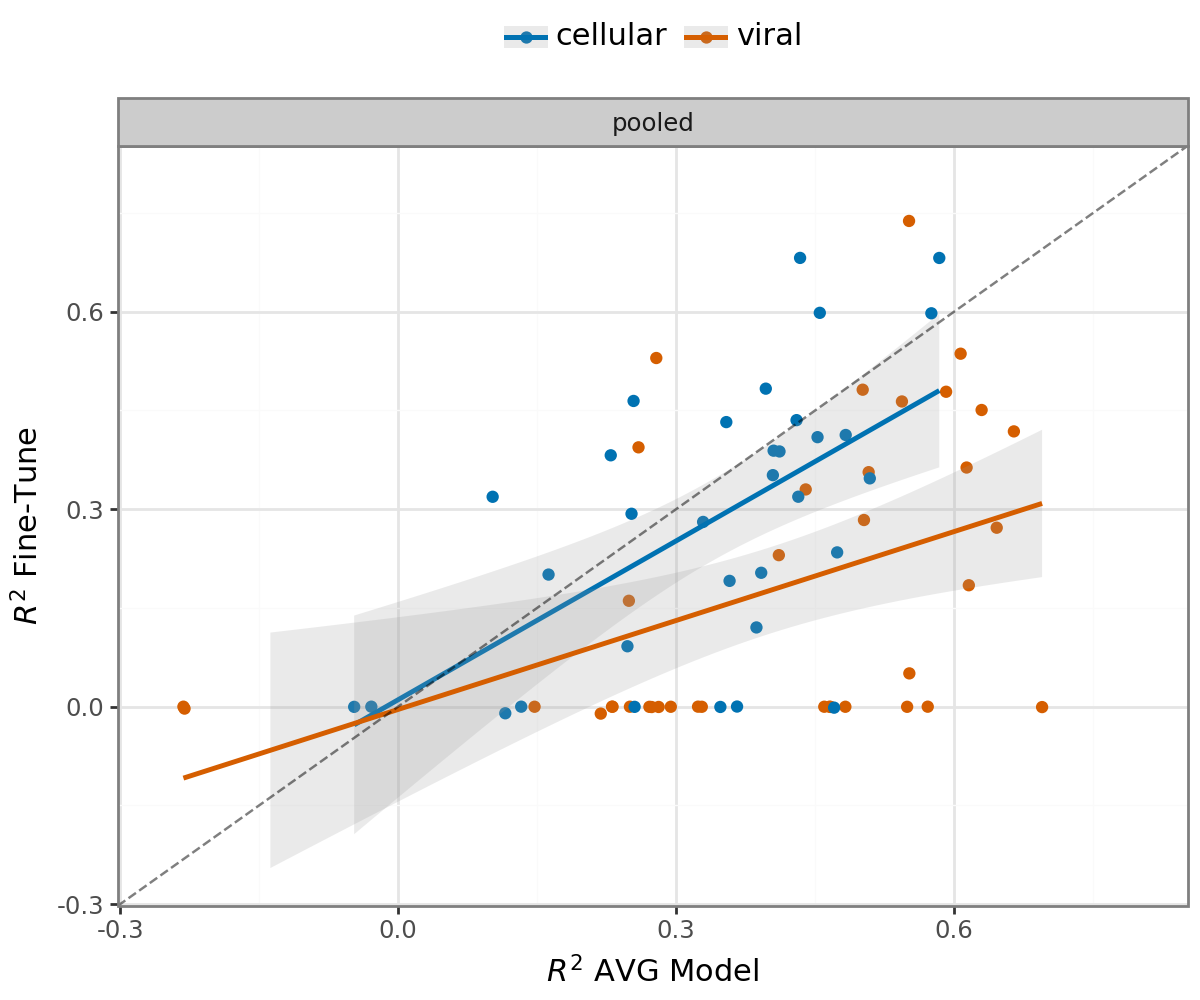

In [99]:
plot = (
    pln.ggplot(res.query('Split == "pooled"'), pln.aes(y='ESM-2_R2', x='R2', color='Source', group='Source'))
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point()
    + pln.geom_smooth(method='lm', se=True,alpha=.2)
    + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
    + pln.theme_bw(11)
    + pln.theme(
        figure_size=(6,5),
        legend_position='top',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    + pln.facet_wrap('~Split', scales='fixed')
    + pln.xlim(-0.25, 0.8)
    + pln.ylim(-0.25, 0.8)
    + pln.labs(
        y="$R^2$ Fine-Tune",
        x="$R^2$ AVG Model"
    )
    )

plot#.save('../experiments/regression/diff_x_r2.png', dpi=600)

# Muation rates

In [ ]:
dfs = []

for source in ['viral', 'cellular']:
    res = {}
    base_dir = f'../data/{source}/metadata/'
    for file in os.listdir(base_dir):
        file_path = os.path.join(base_dir, file)
        dts = file.split('.csv')[0]
        data = pd.read_csv(file_path)
        
        data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
        data['site'] = data['site'].astype(str)
        
        num_mut = len(data['site'].unique())
        protein_length = len(data['sequence'].iloc[0])
        ratio = num_mut / protein_length
    
        res[dts] = [num_mut, protein_length, round(ratio, 3)]
    
    # Create dataframe for this source after processing all files
    df = pd.DataFrame.from_dict(res, orient='index').reset_index()
    df.rename(columns={'index': 'Dataset', 0: '#mutations', 1: 'prot_len', 2: 'ratio'}, inplace=True)
    df['Source'] = source
    dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)
final_df

,Dataset,#mutations,prot_len,ratio,Source
0,HIV1_HV1B9_ENV_DuenasDecamp,20,853,0.023,viral
1,BPP22_COAT_Tsuboyama,40,40,1.000,viral
2,AAV2_CAPSD_Sinai,28,735,0.038,viral
3,IAV_RDRP_Li,754,757,0.996,viral
4,EV_CAPSD_Bakhache,862,862,1.000,viral
...,...,...,...,...,...
74,B3VI55_LIPST_Whitehead2015,439,439,1.000,cellular
75,B3VI55_LIPSTSTABLE,439,439,1.000,cellular
76,RL401_YEAST_Bolon2013,75,128,0.586,cellular
77,RL401_YEAST_Bolon2014,75,128,0.586,cellular


In [94]:
final_df.to_csv('../experiments/mutation_rations.csv')

In [88]:
final_df.groupby(['Source'])['ratio'].mean()

Source
cellular    0.638543
viral       0.840091
Name: ratio, dtype: float64

In [89]:
final_df.groupby(['Source'])['prot_len'].mean()

Source
cellular    442.485714
viral       569.750000
Name: prot_len, dtype: float64

In [90]:
final_df.groupby(['Source'])['#mutations'].mean()

Source
cellular    191.171429
viral       420.568182
Name: #mutations, dtype: float64

In [ ]:
plot = (
    pln.ggplot(final_df, pln.aes(x='ratio', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    +pln.geom_density(alpha=0.6)
    +pln.theme_bw()

)

plot#.save('../experiments/mutation_rations.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: ../experiments/mutation_rations.png
